# Task 7: Coins Detection and Counting using Hough Circle Transform
coins.png is from skimage sample data (it has 24 coins of different sizes)

also tried on smarties.png (opencv sample) as a second test

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

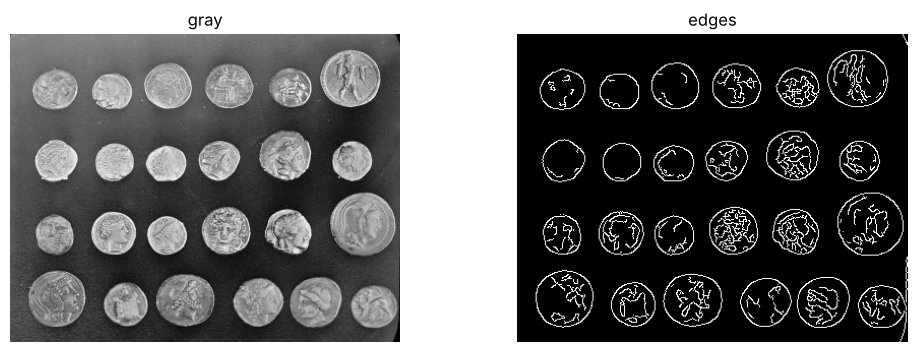

In [2]:
img = cv2.imread("images/coins.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.medianBlur(gray, 5)   # median blur removes the design inside coins

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.imshow(gray, cmap="gray"); plt.title("gray"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(cv2.Canny(blur, 50, 100), cmap="gray"); plt.title("edges"); plt.axis("off")
plt.show()

### hough circles

coins found: 24


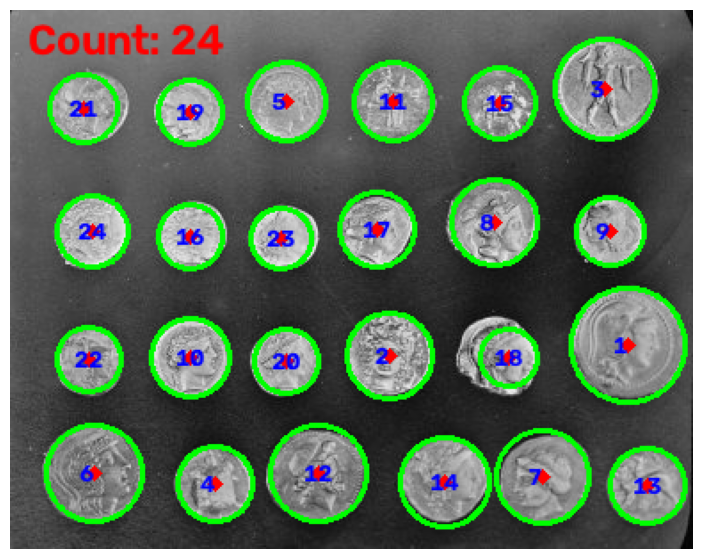

In [3]:
circles = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT, dp=1.2, minDist=25,
                           param1=100, param2=30, minRadius=12, maxRadius=40)
circles = np.round(circles.reshape(-1, 3)).astype(int)
print("coins found:", len(circles))

out = img.copy()
n = 1
for x, y, r in circles:
    cv2.circle(out, (x, y), r, (0, 255, 0), 2)
    cv2.circle(out, (x, y), 2, (0, 0, 255), 3)
    cv2.putText(out, str(n), (x - 8, y + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 0), 2)
    n += 1
cv2.putText(out, "Count: " + str(len(circles)), (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
cv2.imwrite("outputs/task7_coins.png", out)

plt.figure(figsize=(9, 7)); plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()

### small vs big coins
splitting by radius into 2 groups (simple k-means)

small coins: 16  big coins: 8


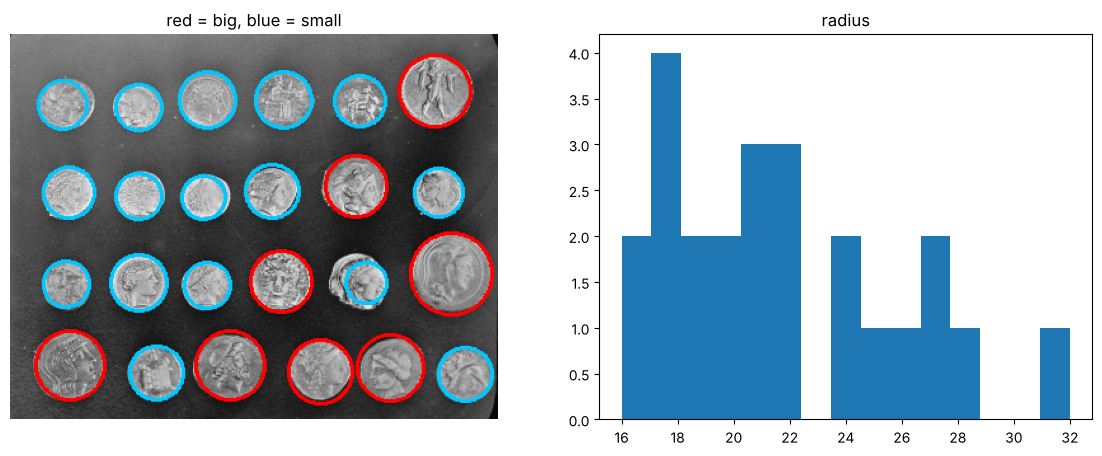

In [4]:
radius = circles[:, 2].astype(float)
c1 = radius.min()
c2 = radius.max()
for i in range(20):
    big = np.abs(radius - c1) > np.abs(radius - c2)
    c1 = radius[~big].mean()
    c2 = radius[big].mean()
print("small coins:", (~big).sum(), " big coins:", big.sum())

out2 = img.copy()
for (x, y, r), b in zip(circles, big):
    if b:
        cv2.circle(out2, (x, y), r, (0, 0, 255), 2)
    else:
        cv2.circle(out2, (x, y), r, (255, 200, 0), 2)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1); plt.imshow(cv2.cvtColor(out2, cv2.COLOR_BGR2RGB)); plt.title("red = big, blue = small"); plt.axis("off")
plt.subplot(1, 2, 2); plt.hist(radius, bins=15); plt.title("radius")
plt.show()

### trying different param2

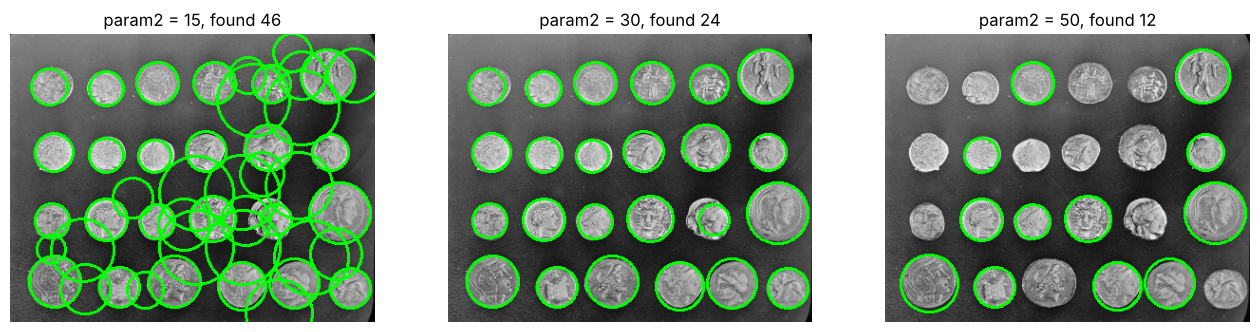

In [5]:
plt.figure(figsize=(16, 4))
for i, p2 in enumerate([15, 30, 50]):
    c = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT, 1.2, 25, param1=100, param2=p2, minRadius=12, maxRadius=40)
    temp = img.copy()
    count = 0
    if c is not None:
        for x, y, r in np.round(c.reshape(-1, 3)).astype(int):
            cv2.circle(temp, (x, y), r, (0, 255, 0), 2)
            count += 1
    plt.subplot(1, 3, i + 1); plt.imshow(cv2.cvtColor(temp, cv2.COLOR_BGR2RGB)); plt.title("param2 = " + str(p2) + ", found " + str(count)); plt.axis("off")
plt.show()

low param2 gives extra fake circles, high param2 misses coins. 30 works best here

### second image

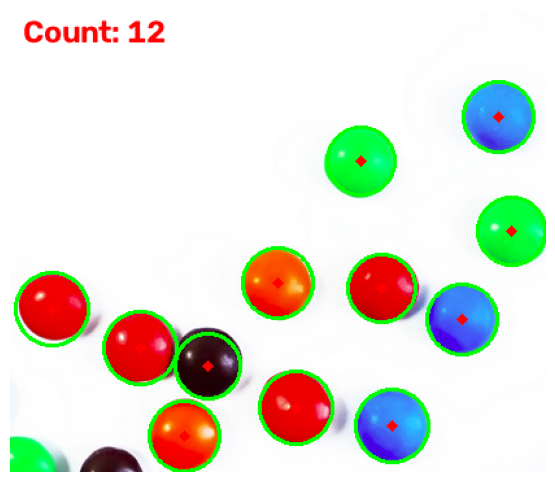

In [6]:
img2 = cv2.imread("images/smarties.png")
blur2 = cv2.medianBlur(cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY), 5)
c = cv2.HoughCircles(blur2, cv2.HOUGH_GRADIENT, 1, minDist=30, param1=100, param2=30, minRadius=15, maxRadius=50)
c = np.round(c.reshape(-1, 3)).astype(int)
out3 = img2.copy()
for x, y, r in c:
    cv2.circle(out3, (x, y), r, (0, 255, 0), 2)
    cv2.circle(out3, (x, y), 2, (0, 0, 255), 3)
cv2.putText(out3, "Count: " + str(len(c)), (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
cv2.imwrite("outputs/task7_smarties.png", out3)
plt.figure(figsize=(8, 6)); plt.imshow(cv2.cvtColor(out3, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()

the ones cut at the border and the dark brown one are missed (not full circle / low contrast)